In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving car_insurance_claim_severity_150k.csv to car_insurance_claim_severity_150k.csv


In [3]:
df=pd.read_csv("/content/car_insurance_claim_severity_150k.csv")

In [4]:
df.head()


,Policy_ID,Driver_Age,Gender,Driving_Experience_Years,Vehicle_Age,Vehicle_Type,Car_Value_USD,Annual_Premium_USD,Coverage_Type,Accident_History,Speeding_Violations,Weather,Road_Type,Claim_Type,Damage_Level,Repair_Cost_USD,Medical_Cost_USD,Vehicle_Damage_Percent,Injury_Severity,Claim_Amount_USD
0,POL100000,56,Male,37,5,Sedan,31762,922,Standard,2,0,Fog,Highway,Theft,Moderate,26087,5405,87,3,47613.18
1,POL100001,69,Female,43,9,Truck,77538,2939,Basic,0,0,Clear,Highway,Collision,Minor,22637,9479,83,2,36089.36
2,POL100002,46,Male,26,13,Hatchback,8604,1550,Premium,0,1,Rain,Highway,Natural Disaster,Total Loss,21063,4249,88,0,73834.40
3,POL100003,32,Male,6,9,SUV,45875,2803,Standard,0,0,Clear,Highway,Natural Disaster,Minor,29905,6816,24,1,33846.61
4,POL100004,60,Female,35,16,SUV,18864,2771,Basic,2,0,Rain,Urban,Theft,Minor,9364,7099,41,8,26443.99


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Policy_ID                 150000 non-null  object 
 1   Driver_Age                150000 non-null  int64  
 2   Gender                    150000 non-null  object 
 3   Driving_Experience_Years  150000 non-null  int64  
 4   Vehicle_Age               150000 non-null  int64  
 5   Vehicle_Type              150000 non-null  object 
 6   Car_Value_USD             150000 non-null  int64  
 7   Annual_Premium_USD        150000 non-null  int64  
 8   Coverage_Type             150000 non-null  object 
 9   Accident_History          150000 non-null  int64  
 10  Speeding_Violations       150000 non-null  int64  
 11  Weather                   150000 non-null  object 
 12  Road_Type                 150000 non-null  object 
 13  Claim_Type                150000 non-null  o

In [6]:
df.describe()

,Driver_Age,Driving_Experience_Years,Vehicle_Age,Car_Value_USD,Annual_Premium_USD,Accident_History,Speeding_Violations,Repair_Cost_USD,Medical_Cost_USD,Vehicle_Damage_Percent,Injury_Severity,Claim_Amount_USD
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000
mean,49.043760,26.808800,10.005660,42527.903033,1654.743847,0.597387,0.996433,15103.808440,9960.91148,50.457180,5.011773,40702.340422
std,18.160657,17.967177,6.062796,21655.464850,780.582482,0.774416,0.998172,8599.524354,5774.79519,28.843141,3.168075,14420.709737
min,18.000000,0.000000,0.000000,5000.000000,300.000000,0.000000,0.000000,200.000000,0.00000,1.000000,0.000000,0.000000
25%,33.000000,11.000000,5.000000,23812.000000,982.000000,0.000000,0.000000,7636.750000,4956.00000,26.000000,2.000000,30850.252500
50%,49.000000,27.000000,10.000000,42533.000000,1657.000000,0.000000,1.000000,15113.000000,9939.00000,51.000000,5.000000,39534.060000
75%,65.000000,42.000000,15.000000,61290.250000,2332.000000,1.000000,2.000000,22548.000000,14949.00000,75.000000,8.000000,48977.280000
max,80.000000,62.000000,20.000000,80000.000000,3000.000000,6.000000,8.000000,30000.000000,20000.00000,100.000000,10.000000,111454.560000


In [7]:
df.isnull().sum()

,0
Policy_ID,0
Driver_Age,0
Gender,0
Driving_Experience_Years,0
Vehicle_Age,0
Vehicle_Type,0
Car_Value_USD,0
Annual_Premium_USD,0
Coverage_Type,0
Accident_History,0


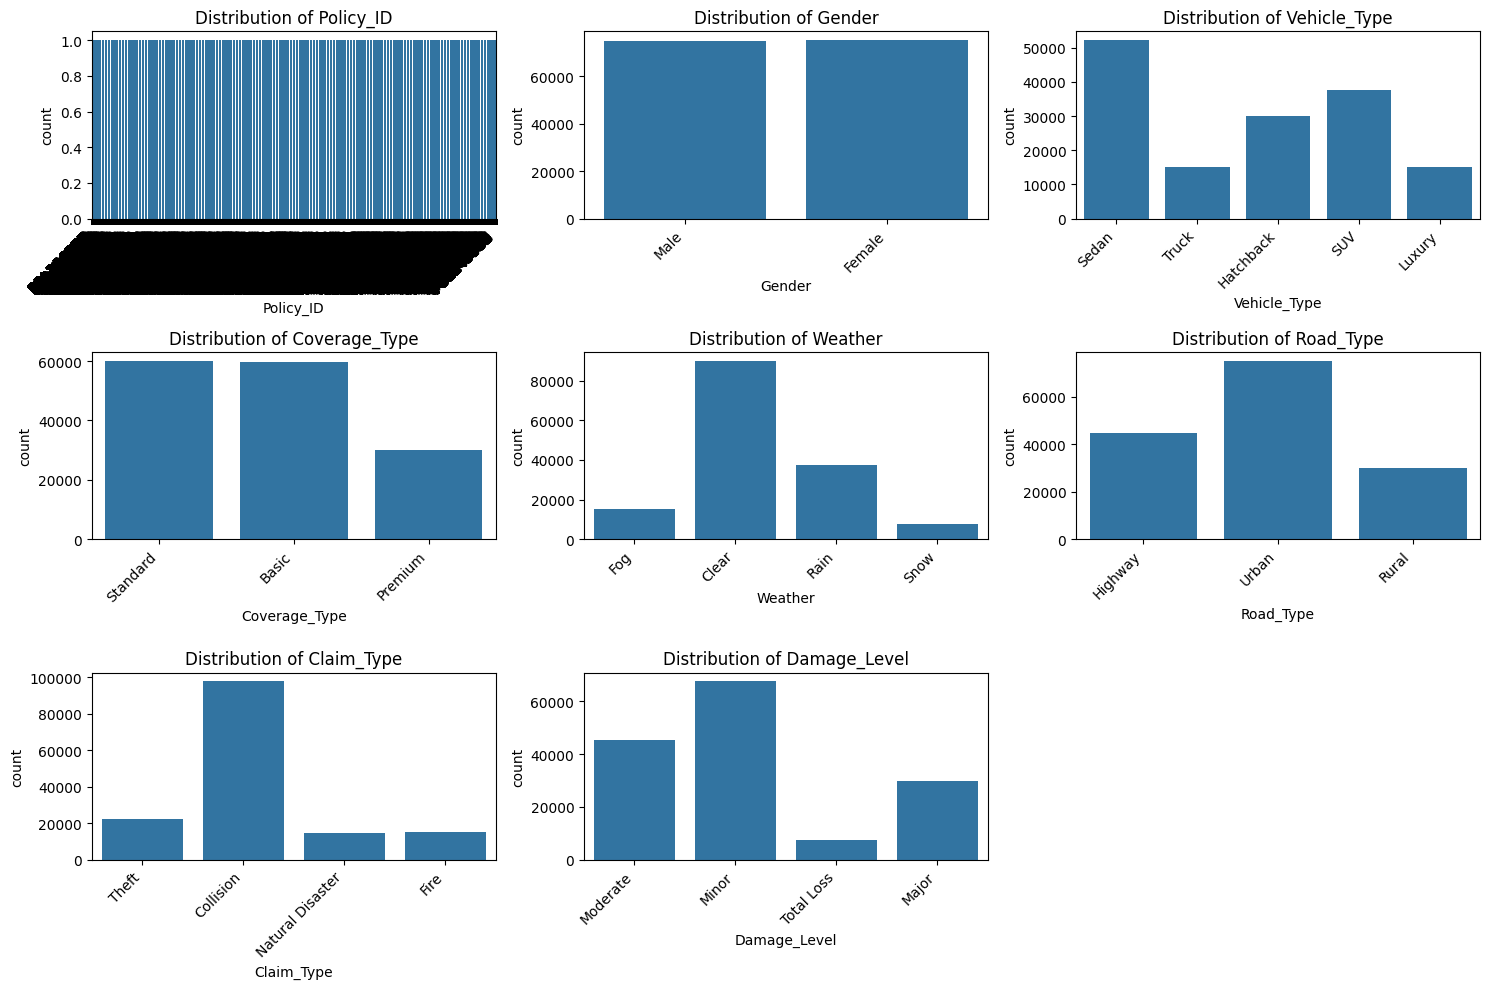

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

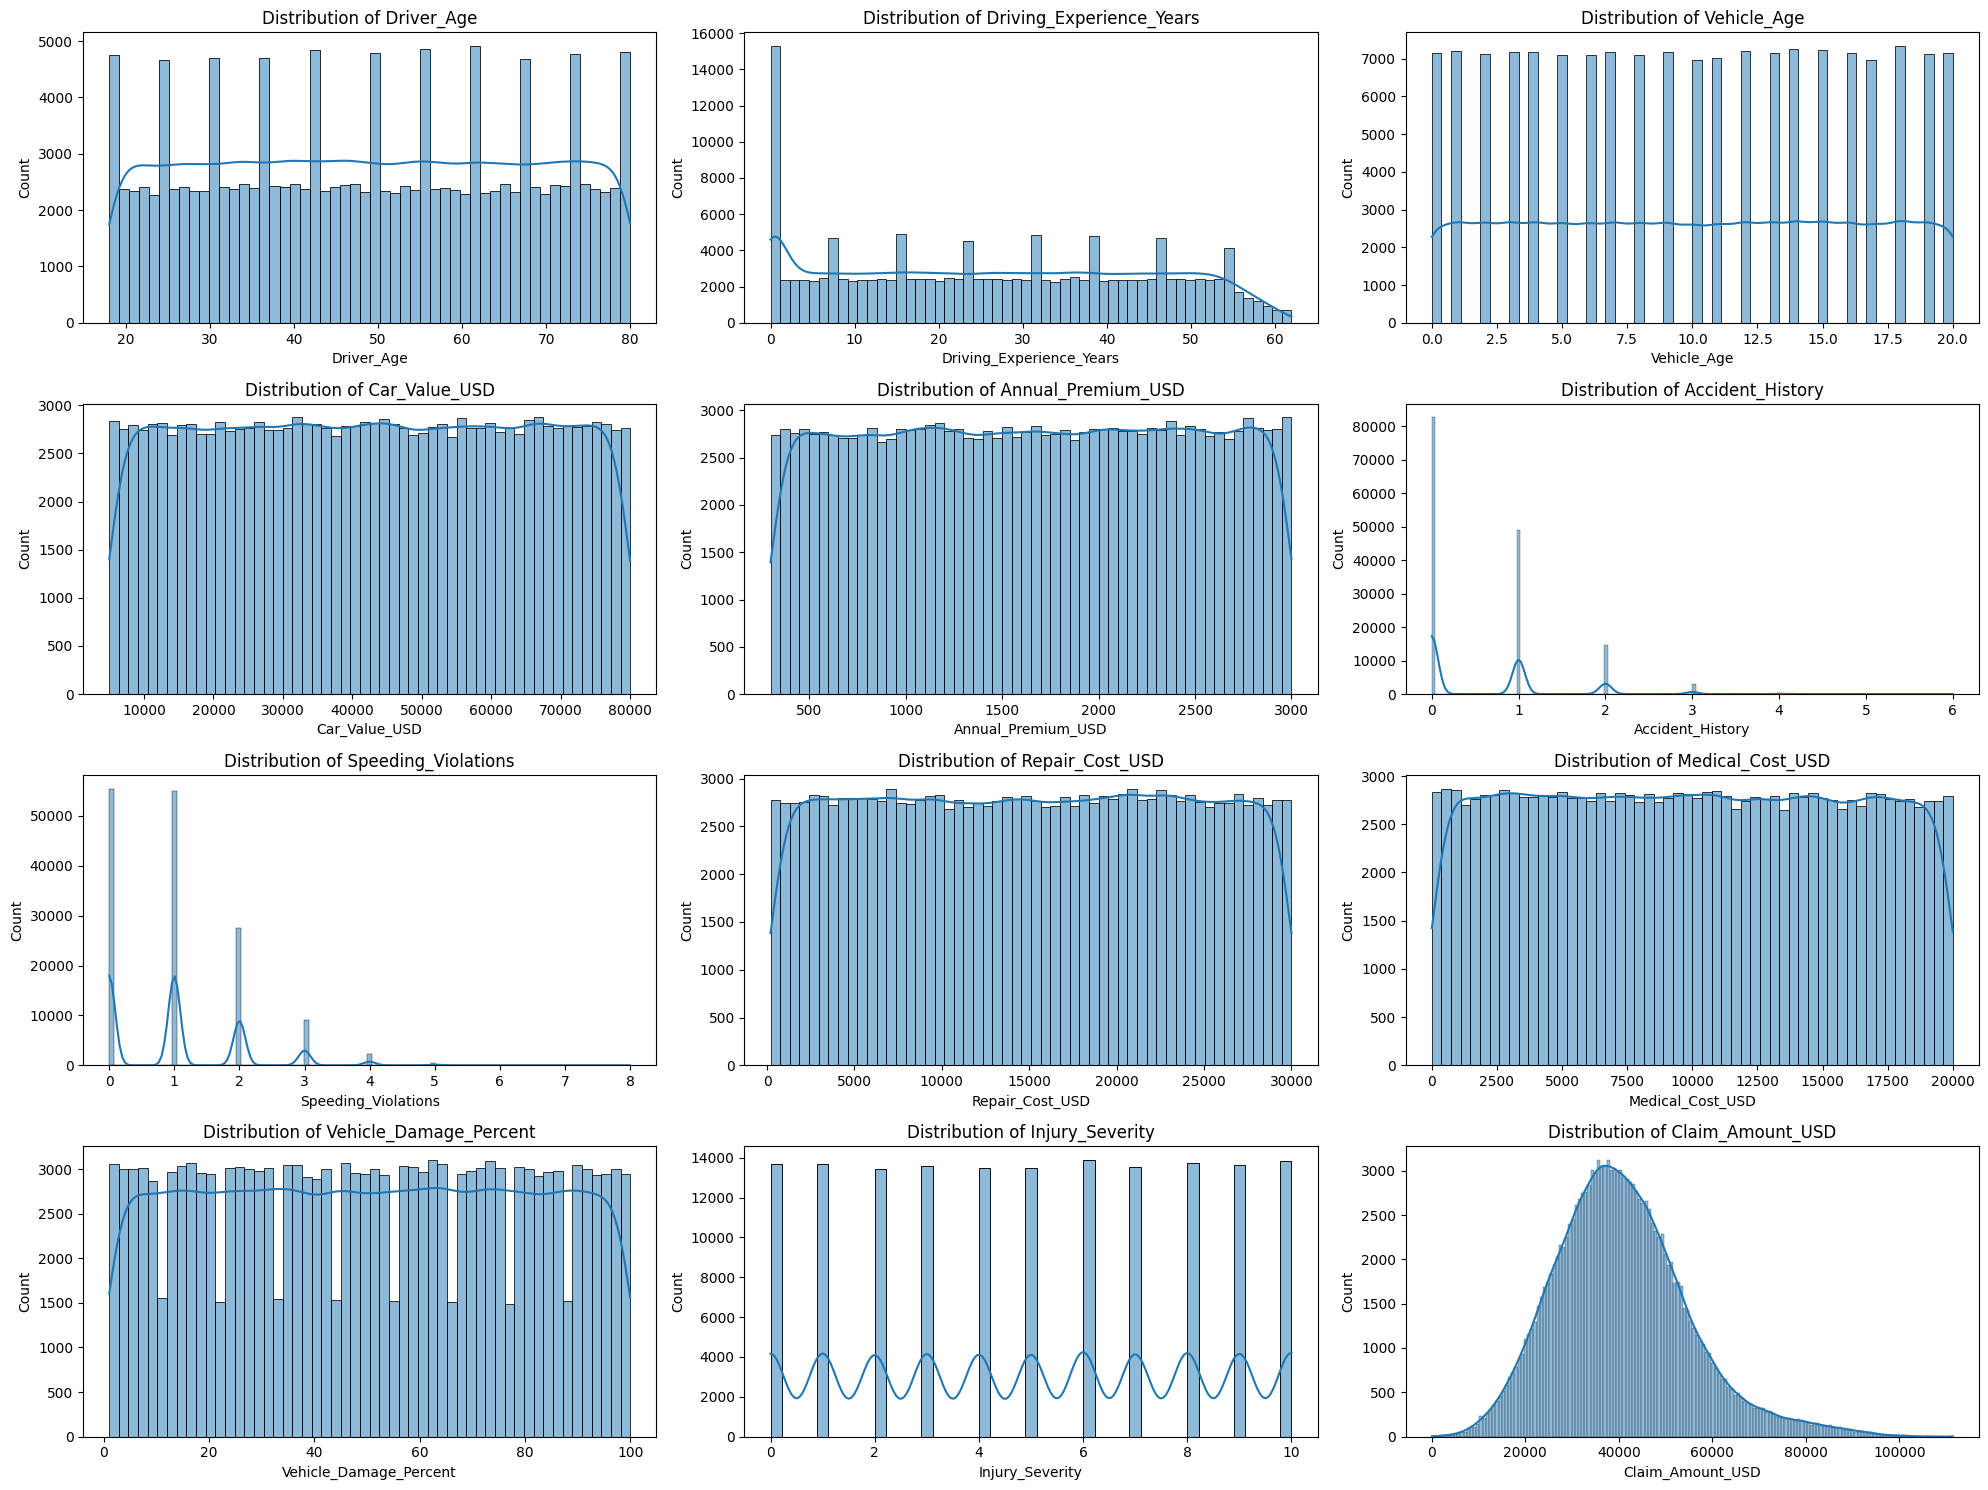

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Policy_ID' in categorical_cols:
    categorical_cols.remove('Policy_ID')

X = df.drop('Claim_Amount_USD', axis=1)
y = df['Claim_Amount_USD']

if 'Claim_Amount_USD' in numerical_cols:
    numerical_cols.remove('Claim_Amount_USD')

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing complete. Shapes of training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preprocessing complete. Shapes of training and testing sets:
X_train shape: (120000, 19)
X_test shape: (30000, 19)
y_train shape: (120000,)
y_test shape: (30000,)


,Actual_Claim_Amount,Predicted_Claim_Amount
59770,60126.35,56469.130780
21362,31652.09,33008.613973
127324,36364.75,38168.618385
140509,36681.22,40432.500695
144297,73141.94,70244.597647
96370,10426.81,10050.834677
49742,34509.79,37516.756317
47389,49247.84,46370.709608
58378,28411.25,30312.655388
69047,36599.93,37986.533527


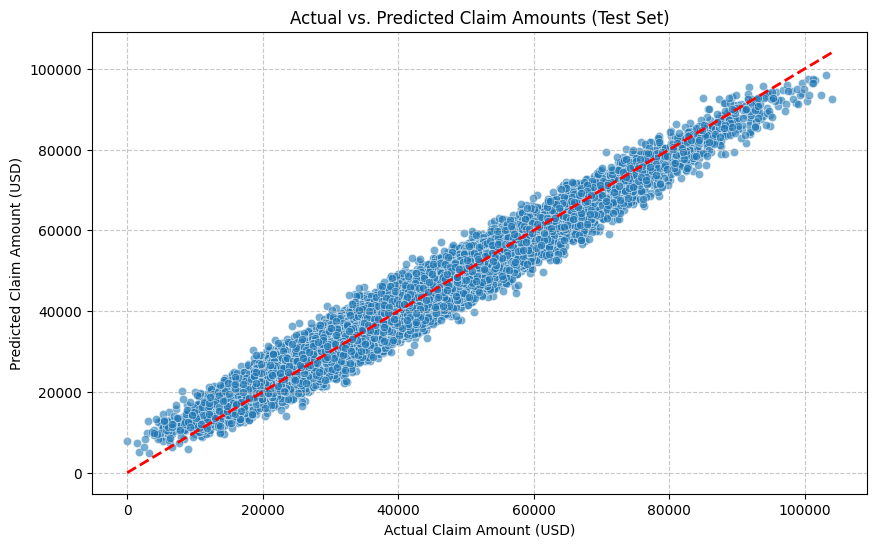

In [17]:

predictions_df = pd.DataFrame({
    'Actual_Claim_Amount': y_test,
    'Predicted_Claim_Amount': y_pred
})

display(predictions_df.head(10))

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel('Actual Claim Amount (USD)')
plt.ylabel('Predicted Claim Amount (USD)')
plt.title('Actual vs. Predicted Claim Amounts (Test Set)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [20]:
import joblib
joblib.dump(model_pipeline,'Car Insurance Claim Severity Estimator.joblib')

['Car Insurance Claim Severity Estimator.joblib']